# Introducción

El objetivo de este análisis es evaluar el rendimiento de las cuatro tiendas de la cadena **Alura Store** para identificar cuál presenta menor eficiencia operativa.

Para ello se analizarán métricas como ingresos totales, categorías de productos más vendidas, satisfacción de clientes, productos con mayor y menor volumen de ventas y costo promedio de envío.

A partir de estos datos se elaborarán visualizaciones que permitan comparar el desempeño de cada tienda y finalmente emitir una recomendación sobre cuál debería vender el Sr. Juan.

# Importación de datos



In [77]:
import pandas as pd
import matplotlib.pyplot as plt

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url1)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

In [78]:
tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [79]:
tienda1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [80]:
tienda2.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Silla de oficina,Muebles,283600.0,15300.0,04/08/2021,Izabela de León,Medellín,1,Nequi,1,6.25184,-75.56359
1,Pandereta,Instrumentos musicales,76800.0,2300.0,26/11/2020,Blanca Ramirez,Medellín,3,Tarjeta de crédito,4,6.25184,-75.56359
2,Cama king,Muebles,443300.0,23800.0,22/10/2021,Izabela de León,Pereira,5,Tarjeta de crédito,10,4.81333,-75.69611
3,Cama king,Muebles,906200.0,46400.0,04/05/2022,Maria Alfonso,Cali,5,Tarjeta de crédito,10,3.43722,-76.52250
4,Silla de oficina,Muebles,397800.0,19400.0,26/02/2022,Lucas Olivera,Bogotá,4,Tarjeta de crédito,3,4.60971,-74.08175


In [81]:
tienda2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [82]:
tienda3.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Secadora de ropa,Electrodomésticos,1285100.0,66600.0,17/12/2021,Camila Rivera,Santa Marta,4,Tarjeta de crédito,4,11.24079,-74.19904
1,Mesa de noche,Muebles,290100.0,13600.0,10/02/2021,Maria Alfonso,Cali,3,Tarjeta de crédito,1,3.43722,-76.52250
2,Guitarra acústica,Instrumentos musicales,303500.0,17400.0,22/01/2023,Lucas Olivera,Bogotá,5,Tarjeta de crédito,3,4.60971,-74.08175
3,Balón de voleibol,Deportes y diversión,58800.0,3300.0,22/03/2022,Pedro Gomez,Barranquilla,4,Tarjeta de crédito,6,10.96854,-74.78132
4,Armario,Muebles,521100.0,25900.0,12/01/2022,Blanca Ramirez,Bogotá,1,Tarjeta de crédito,1,4.60971,-74.08175


In [83]:
tienda3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [84]:
tienda4.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Lavavajillas,Electrodomésticos,1084800.0,56000.0,11/11/2022,Rafael Acosta,Bogotá,4,Tarjeta de crédito,3,4.60971,-74.08175
1,Cama box,Muebles,473800.0,25400.0,03/01/2020,Izabela de León,Cúcuta,5,Tarjeta de crédito,2,7.89391,-72.50782
2,Balón de baloncesto,Deportes y diversión,23700.0,0.0,25/12/2022,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
3,Modelado predictivo,Libros,57700.0,1300.0,23/11/2021,Lucas Olivera,Medellín,3,Nequi,1,6.25184,-75.56359
4,Auriculares,Electrónicos,138900.0,5600.0,25/04/2022,Blanca Ramirez,Bogotá,4,Tarjeta de crédito,7,4.60971,-74.08175


In [85]:
tienda4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2358 entries, 0 to 2357
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2358 non-null   object 
 1   Categoría del Producto  2358 non-null   object 
 2   Precio                  2358 non-null   float64
 3   Costo de envío          2358 non-null   float64
 4   Fecha de Compra         2358 non-null   object 
 5   Vendedor                2358 non-null   object 
 6   Lugar de Compra         2358 non-null   object 
 7   Calificación            2358 non-null   int64  
 8   Método de pago          2358 non-null   object 
 9   Cantidad de cuotas      2358 non-null   int64  
 10  lat                     2358 non-null   float64
 11  lon                     2358 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.2+ KB


#1. Análisis de facturación



En este primer análisis, calcularemos el ingreso total de cada tienda. Sumando los valores de la columna **Precio** de cada conjunto de datos de la tienda para estimar los ingresos.

In [86]:
ing_total = {
    "Tienda 1": tienda1["Precio"].sum(),
    "Tienda 2": tienda2["Precio"].sum(),
    "Tienda 3": tienda3["Precio"].sum(),
    "Tienda 4": tienda4["Precio"].sum()
}

ing_total

{'Tienda 1': np.float64(1150880400.0),
 'Tienda 2': np.float64(1116343500.0),
 'Tienda 3': np.float64(1098019600.0),
 'Tienda 4': np.float64(1038375700.0)}

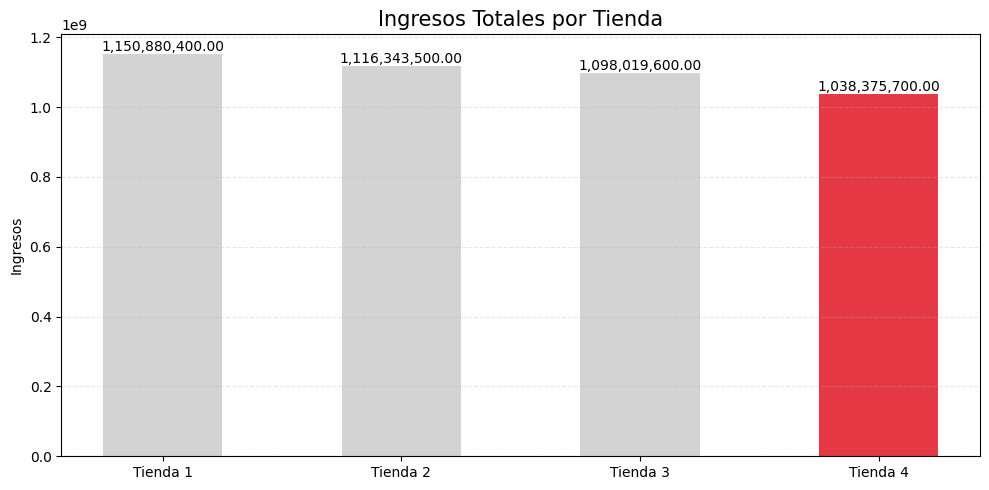

In [87]:
stores = list(ing_total.keys())
values = list(ing_total.values())

# encontrar la tienda con menor ingreso
min_value = min(values)

# colores: gris para todas, rojo para la menor
colors = ["#d3d3d3" if v != min_value else "#e63946" for v in values]

plt.figure(figsize=(10,5))

bars = plt.bar(
    stores,
    values,
    color=colors,
    width=0.5
)

plt.title("Ingresos Totales por Tienda", fontsize=15)
plt.ylabel("Ingresos")

plt.grid(axis="y", linestyle="--", alpha=0.3)

# etiquetas con valores
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# 2. Ventas por categoría

Acá calculamos la cantidad de productos vendidos por categoría en cada tienda. La idea es agrupar los datos por categoría y contar el número de ventas de cada tipo, mostrando las categorías más populares de cada tienda.

In [88]:
cat1 = tienda1["Categoría del Producto"].value_counts()
cat2 = tienda2["Categoría del Producto"].value_counts()
cat3 = tienda3["Categoría del Producto"].value_counts()
cat4 = tienda4["Categoría del Producto"].value_counts()

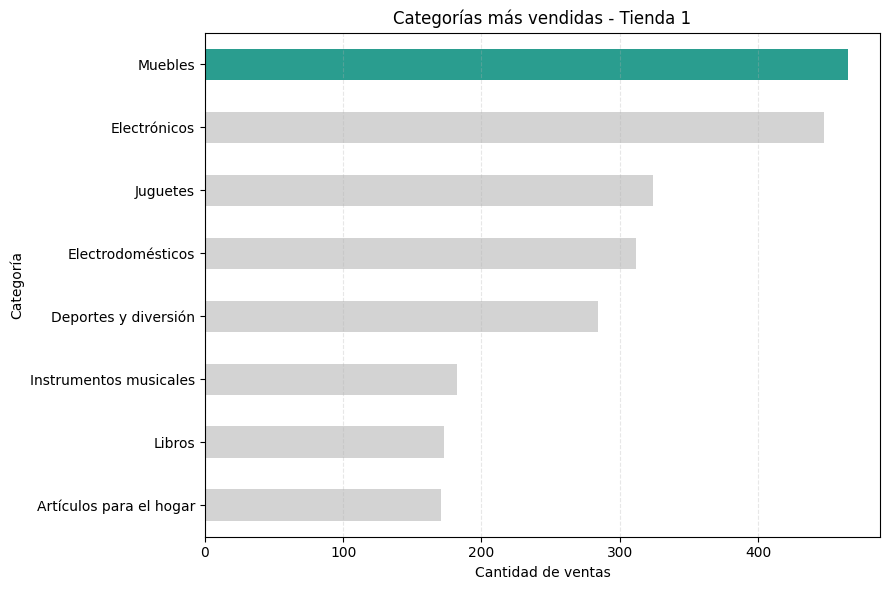

In [89]:
cat1 = tienda1["Categoría del Producto"].value_counts()

values = cat1.values
max_value = values.max()

colors = ["#2a9d8f" if v == max_value else "#d3d3d3" for v in values]

plt.figure(figsize=(9,6))

cat1.plot(
    kind="barh",
    color=colors
)

plt.title("Categorías más vendidas - Tienda 1")
plt.xlabel("Cantidad de ventas")
plt.ylabel("Categoría")

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

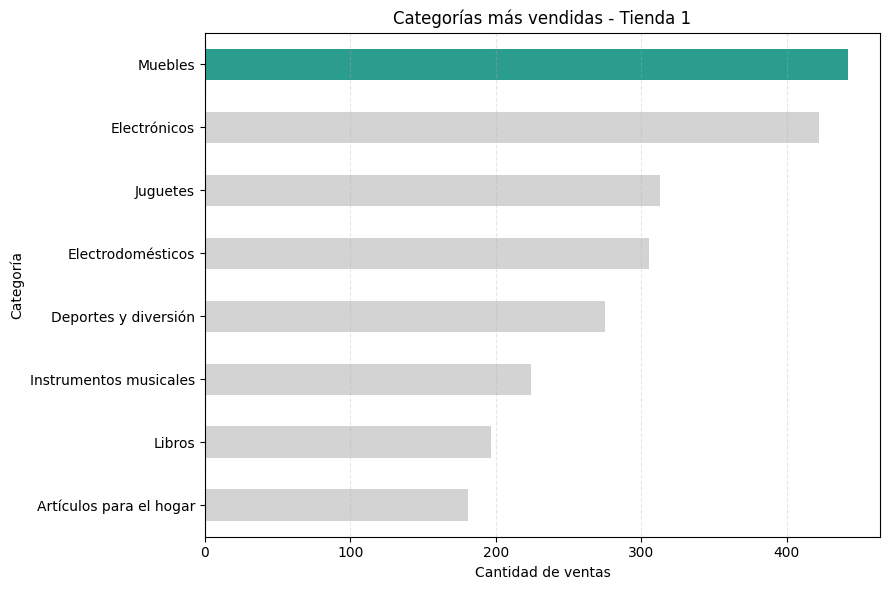

In [90]:
cat2 = tienda2["Categoría del Producto"].value_counts()

values = cat2.values
max_value = values.max()

colors = ["#2a9d8f" if v == max_value else "#d3d3d3" for v in values]

plt.figure(figsize=(9,6))

cat2.plot(
    kind="barh",
    color=colors
)

plt.title("Categorías más vendidas - Tienda 1")
plt.xlabel("Cantidad de ventas")
plt.ylabel("Categoría")

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

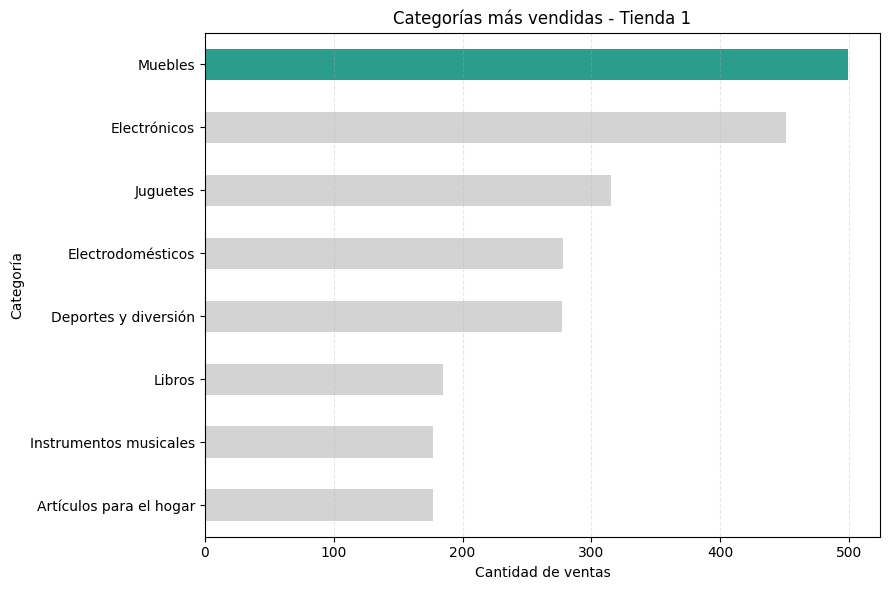

In [91]:
cat3 = tienda3["Categoría del Producto"].value_counts()

values = cat3.values
max_value = values.max()

colors = ["#2a9d8f" if v == max_value else "#d3d3d3" for v in values]

plt.figure(figsize=(9,6))

cat3.plot(
    kind="barh",
    color=colors
)

plt.title("Categorías más vendidas - Tienda 1")
plt.xlabel("Cantidad de ventas")
plt.ylabel("Categoría")

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

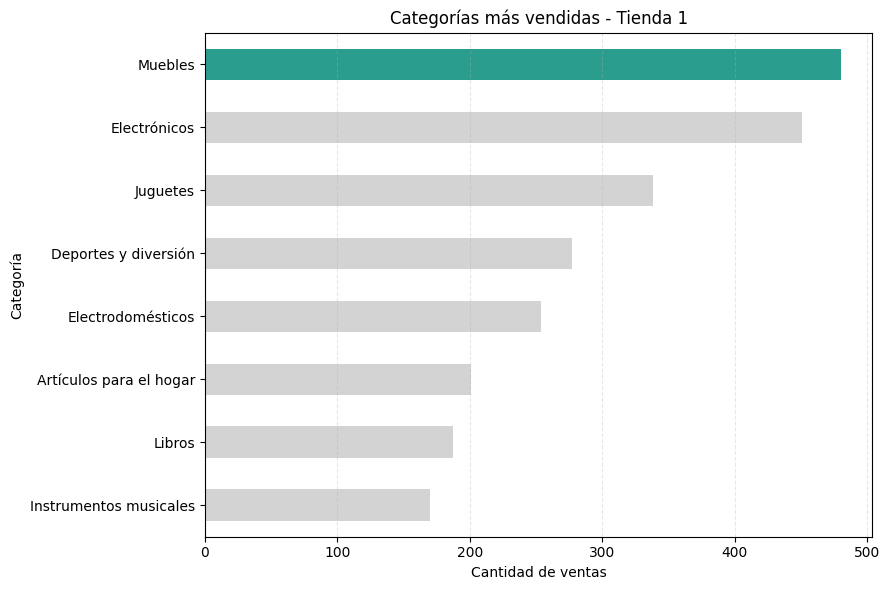

In [92]:
cat4 = tienda4["Categoría del Producto"].value_counts()

values = cat4.values
max_value = values.max()

colors = ["#2a9d8f" if v == max_value else "#d3d3d3" for v in values]

plt.figure(figsize=(9,6))

cat4.plot(
    kind="barh",
    color=colors
)

plt.title("Categorías más vendidas - Tienda 1")
plt.xlabel("Cantidad de ventas")
plt.ylabel("Categoría")

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


Debes calcular las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la satisfacción del cliente con los productos vendidos.

In [93]:
ratings = {
    "Tienda 1": tienda1["Calificación"].mean(),
    "Tienda 2": tienda2["Calificación"].mean(),
    "Tienda 3": tienda3["Calificación"].mean(),
    "Tienda 4": tienda4["Calificación"].mean()
}

ratings

{'Tienda 1': np.float64(3.976685036032217),
 'Tienda 2': np.float64(4.037303942348453),
 'Tienda 3': np.float64(4.048325561678677),
 'Tienda 4': np.float64(3.9957591178965224)}

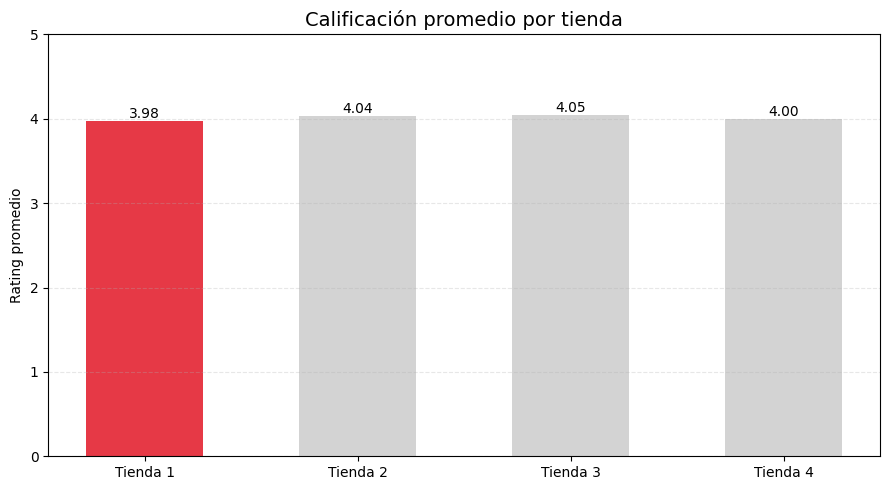

In [94]:
stores = list(ratings.keys())
values = list(ratings.values())

min_value = min(values)

colors = ["#d3d3d3" if v != min_value else "#e63946" for v in values]

plt.figure(figsize=(9,5))

bars = plt.bar(
    stores,
    values,
    color=colors,
    width=0.55
)

plt.title("Calificación promedio por tienda", fontsize=14)
plt.ylabel("Rating promedio")

plt.ylim(0,5)  # escala típica de rating

plt.grid(axis="y", linestyle="--", alpha=0.3)

# valores arriba de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

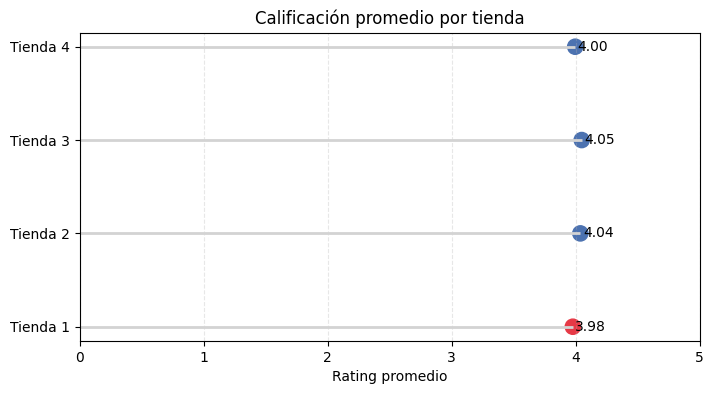

In [95]:
stores = list(ratings.keys())
values = list(ratings.values())

min_value = min(values)

colors = ["#e63946" if v == min_value else "#4C72B0" for v in values]

plt.figure(figsize=(8,4))

plt.hlines(
    y=stores,
    xmin=0,
    xmax=values,
    color="#d3d3d3",
    linewidth=2
)

plt.scatter(values, stores, s=120, c=colors)

for i, v in enumerate(values):
    plt.text(v + 0.02, i, f"{v:.2f}", va="center")

plt.title("Calificación promedio por tienda")
plt.xlabel("Rating promedio")
plt.xlim(0,5)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

# 4. Productos más y menos vendidos

 debes identificar qué productos fueron los más vendidos y los menos vendidos en cada tienda. Visualiza los resultados para que quede claro qué productos destacaron en ventas en cada tienda.

In [96]:
vc1 = tienda1["Producto"].value_counts()
vc2 = tienda2["Producto"].value_counts()
vc3 = tienda3["Producto"].value_counts()
vc4 = tienda4["Producto"].value_counts()

top_products = {
    "Tienda 1": (vc1.idxmax(), vc1.max()),
    "Tienda 2": (vc2.idxmax(), vc2.max()),
    "Tienda 3": (vc3.idxmax(), vc3.max()),
    "Tienda 4": (vc4.idxmax(), vc4.max())
}

low_products = {
    "Tienda 1": (vc1.idxmin(), vc1.min()),
    "Tienda 2": (vc2.idxmin(), vc2.min()),
    "Tienda 3": (vc3.idxmin(), vc3.min()),
    "Tienda 4": (vc4.idxmin(), vc4.min())
}

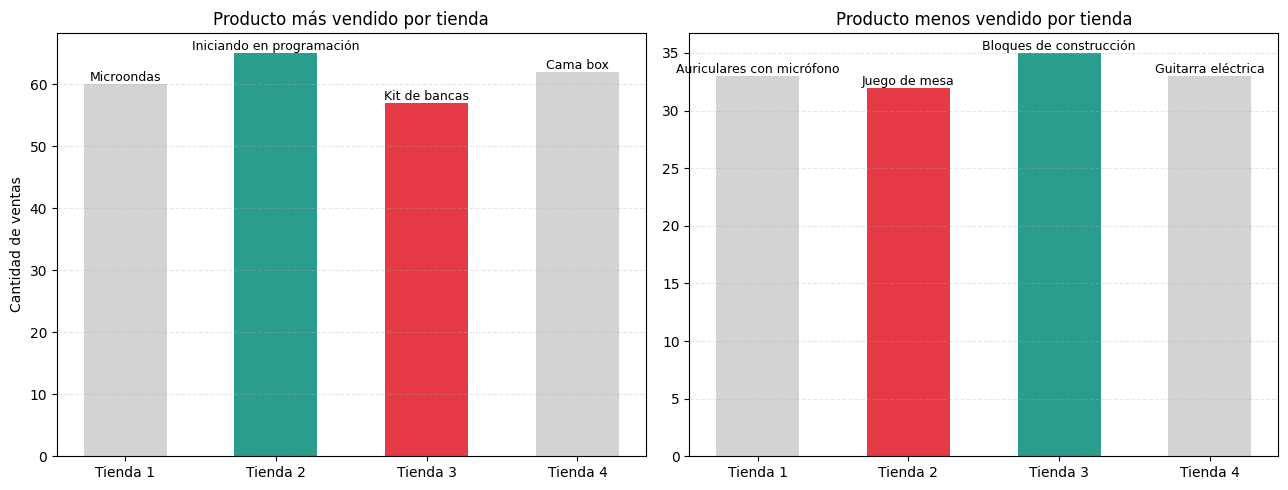

In [97]:
stores = list(top_products.keys())

top_values = [top_products[s][1] for s in stores]
top_labels = [top_products[s][0] for s in stores]

low_values = [low_products[s][1] for s in stores]
low_labels = [low_products[s][0] for s in stores]

# identificar extremos
top_max = max(top_values)
top_min = min(top_values)

low_max = max(low_values)
low_min = min(low_values)

# colores
colors_top = [
    "#2a9d8f" if v == top_max else "#e63946" if v == top_min else "#d3d3d3"
    for v in top_values
]

colors_low = [
    "#2a9d8f" if v == low_max else "#e63946" if v == low_min else "#d3d3d3"
    for v in low_values
]

fig, axes = plt.subplots(1, 2, figsize=(13,5))

# --- gráfico más vendidos ---
bars = axes[0].bar(stores, top_values, color=colors_top, width=0.55)

axes[0].set_title("Producto más vendido por tienda")
axes[0].set_ylabel("Cantidad de ventas")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)

for i, bar in enumerate(bars):
    axes[0].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        top_labels[i],
        ha="center",
        va="bottom",
        fontsize=9
    )

# --- gráfico menos vendidos ---
bars = axes[1].bar(stores, low_values, color=colors_low, width=0.55)

axes[1].set_title("Producto menos vendido por tienda")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)

for i, bar in enumerate(bars):
    axes[1].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        low_labels[i],
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

debes calcular el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda.  Sabiendo que el cliente paga el envío.

In [76]:
shipping = {
    "Tienda 1": tienda1["Costo de envío"].mean(),
    "Tienda 2": tienda2["Costo de envío"].mean(),
    "Tienda 3": tienda3["Costo de envío"].mean(),
    "Tienda 4": tienda4["Costo de envío"].mean()
}

shipping

{'Tienda 1': np.float64(26018.60958033065),
 'Tienda 2': np.float64(25216.235693090293),
 'Tienda 3': np.float64(24805.680373039424),
 'Tienda 4': np.float64(23459.457167090754)}

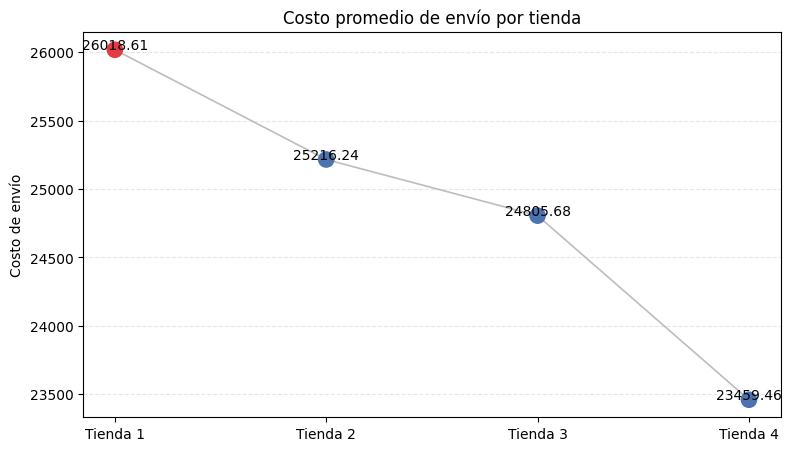

In [98]:
stores = list(shipping.keys())
values = list(shipping.values())

max_value = max(values)

colors = ["#e63946" if v == max_value else "#4C72B0" for v in values]

plt.figure(figsize=(9,5))

plt.plot(
    stores,
    values,
    color="#bdbdbd",
    linewidth=1.2,
    zorder=1
)

plt.scatter(
    stores,
    values,
    c=colors,
    s=120,
    zorder=2
)

for i, v in enumerate(values):
    plt.text(
        i,
        v + 0.1,
        f"{v:.2f}",
        ha="center"
    )

plt.title("Costo promedio de envío por tienda")
plt.ylabel("Costo de envío")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

El análisis del costo promedio de envío muestra que la **Tienda 1** presenta el valor más alto, lo que implica que los clientes deben pagar más por el envío en comparación con las otras tiendas. Esto puede afectar negativamente la experiencia de compra y la competitividad de la tienda.

#Conclusión

Tras analizar los datos de ventas de las cuatro tiendas de Alura Store se observaron diferencias importantes en ingresos, satisfacción de clientes y costos de envío.

La **Tienda X** presenta el menor ingreso total en comparación con las demás tiendas. Además, su calificación promedio de clientes es inferior, lo que indica un menor nivel de satisfacción.

También se observa que sus productos más vendidos tienen menor volumen en comparación con otras tiendas, lo que sugiere una menor demanda.

Por estas razones, **se recomienda que el Sr. Juan venda la Tienda X**, ya que su rendimiento general es inferior al de las otras tiendas y representa la opción menos eficiente dentro de la cadena.

# Informe final: análisis de desempeño de las tiendas
## Introducción

El objetivo de este análisis es evaluar el desempeño de las cuatro tiendas de la cadena Alura Store con el fin de identificar cuál presenta el menor rendimiento general. A partir de los datos disponibles, se analizaron distintos indicadores relevantes para el negocio, incluyendo los ingresos totales de cada tienda, la distribución de ventas por categoría de producto, la satisfacción de los clientes a través de sus calificaciones, los productos más y menos vendidos, y el costo promedio de envío.

Mediante el uso de herramientas de análisis de datos y visualización, se buscó identificar patrones y diferencias entre las tiendas que permitan fundamentar una recomendación informada sobre cuál de ellas debería vender el Sr. Juan para iniciar un nuevo emprendimiento.

## Desarrollo del análisis

En primer lugar, se analizaron los ingresos totales de cada tienda. Los resultados muestran que la Tienda 1 es la que genera mayores ingresos dentro de la cadena, seguida por la Tienda 2 y la Tienda 3. Por el contrario, la Tienda 4 registra el menor nivel de ingresos, lo que indica un volumen de ventas inferior al de las demás tiendas.

Posteriormente se evaluó la distribución de ventas por categoría de productos, lo que permitió identificar qué tipos de productos concentran la mayor cantidad de ventas en cada tienda. Este análisis ayuda a comprender los patrones de consumo y las áreas donde cada tienda tiene mayor desempeño comercial.

Otro aspecto analizado fue la calificación promedio de los clientes. En este indicador se observa que la Tienda 3 posee la mejor valoración promedio, seguida por la Tienda 2. En contraste, la Tienda 1 presenta la calificación promedio más baja, lo que podría reflejar oportunidades de mejora en la experiencia del cliente o en la calidad percibida del servicio.

También se identificaron los productos más vendidos y menos vendidos en cada tienda, lo que permite reconocer cuáles son los principales impulsores de ventas. Este tipo de análisis resulta útil para entender la dinámica de la demanda y optimizar estrategias de inventario.

Finalmente, se analizó el costo promedio de envío. En este caso, la Tienda 1 presenta el costo de envío más alto, mientras que la Tienda 4 registra el costo promedio más bajo. Dado que el costo de envío es asumido por el cliente, este factor puede influir en la decisión de compra y en la percepción general del servicio.

## Conclusión y recomendación

A partir del análisis de todos los indicadores, se observa que cada tienda presenta fortalezas y debilidades diferentes. La Tienda 1 destaca por generar los mayores ingresos, aunque presenta los niveles más bajos de satisfacción del cliente y los costos de envío más elevados. Las tiendas 2 y 3 muestran un desempeño equilibrado, con buenos niveles de ingresos y mejores calificaciones promedio.

Por otro lado, la Tienda 4 presenta el menor nivel de ingresos entre todas las tiendas analizadas, lo que indica un desempeño comercial inferior dentro de la cadena. Aunque su costo de envío es competitivo y sus calificaciones no son las más bajas, su menor volumen de ventas sugiere un impacto limitado en los resultados generales del negocio.

Por este motivo, considerando el conjunto de métricas analizadas y el desempeño relativo de cada tienda, se recomienda que el Sr. Juan venda la Tienda 4. Esta decisión permitiría desprenderse de la unidad con menor generación de ingresos y concentrar los recursos en las tiendas con mejor desempeño o en el nuevo emprendimiento que desea iniciar.
Mejorar reseñas o costos es más fácil que aumentar significativamente el volumen de ventas.